# Interpolación polinomial de Lagrange

La tarea de encontrar un polinomio de grado uno que pase por los puntos $(x_{0}, y_{0})$ y $(x_{1}, y_{1})$ es equivalente a aproximar una función $f$, para la cual $f(x_{0}) = y_{0}$ y $f(x_{1}) = y_{1}$, mediante un polinomio de primer grado que interpole —o coincida con— los valores de $f$ en los puntos dados. El uso de este polinomio para realizar una aproximación dentro del intervalo definido por dichos puntos se denomina **interpolación polinómica**.

Dadas las funciones

$$
 L_{0}(x) = \frac{x-x_{1}}{x_{0}-x_{1}}, \quad L_{1}(x) = \frac{x - x_{0}}{x_{1}-x_{0}}.
$$

El **polinomio de interpolación de Lagrange** lineal que pasa por $(x_{0} , y_{0} )$ y $(x_{1} , y_{1})$ es

$$
 P(x) = L_{0}(x)~f(x_{0}) + L_{1}(x)~f(x_{1}) = \frac{x-x_{1}}{x_{0}-x_{1}}f(x_{0}) + \frac{x-x_{0}}{x_{1}-x_{0}}f(x_{1})
$$

**Ejemplo 1.** Determine el polinomio de interpolación lineal de Lagrange que pasa por los puntos $(2, 4)$ y $(5, 1)$.

En esta caso se tiene

$$
 L_{0}(x) = \frac{x-5}{2-5} = -\frac{1}{3}(x-5), \quad L_{1}(x) = \frac{x - 2}{5-2} = \frac{1}{3}(x-2),
$$
tal que

$$
 P(x) = -\frac{1}{3}(x-5)\cdot 4 + \frac{1}{3}(x-2)\cdot 1 = -\frac{4}{3}x + \frac{20}{3} + \frac{1}{3}x - \frac{2}{3} = -x + 6.
$$

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# Suprimir advertencias menores de integración durante los bucles de optimización
import warnings
warnings.filterwarnings("ignore")

# Configurar el estilo de graficación para una mejor visualización
plt.style.use('ggplot')

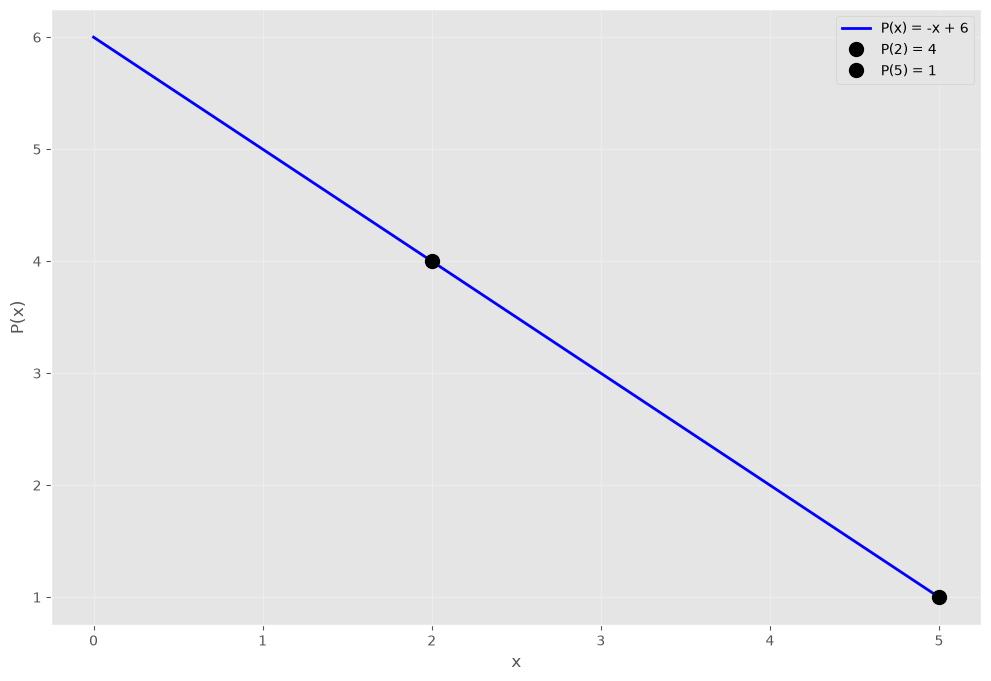

In [7]:
x = np.linspace(0, 5, 100)

P = lambda x: - x + 6 # Función original

# Graficar
plt.figure(figsize=(12, 8))
plt.plot(x, P(x), 'b', linewidth=2, label='P(x) = -x + 6')
plt.plot(2, 4, 'ko', markersize=10, label='P(2) = 4')
plt.plot(5, 1, 'ko', markersize=10, label='P(5) = 1')
plt.xlabel('x')
plt.ylabel('P(x)')
plt.grid(True, alpha=0.3)
plt.axis('tight')
plt.legend()
plt.show()

Para generalizar el concepto de interpolación lineal, consideremos la construcción de un polinomio de grado a lo sumo $n$ que pase por los $n + 1$ puntos

$$
 (x_{0} , f(x_{0})), (x_{1} , f (x_{1} )), \dots , (x_{n} , f (x_{n} )).
$$

Para cada $k = 0, 1, \dots, n$, una función $L_{n,k} (x)$ con la propiedad de que $L_{n,k} (x_{i} ) = 0$ cuando $i \neq k$ y $L_{n,k} (x_{k} ) = 1$. Para satisfacer $L_{n,k} (x_{i} ) = 0$ para cada $i \neq k$, se requiere que el numerador de $L_{n,k} (x)$ contenga el término

$$
 (x − x_{0})(x − x_{1}) \cdots (x − x_{k−1})(x − x_{k+1}) \cdots (x − x_{n}).
$$

Para satisfacer $L_{n,k}(xk) = 1$, el denominador de $L_{n,k}(x)$ debe ser este mismo término, pero evaluado en $x = x_{k}$. Por tanto

$$
 L_{n,k}(x) = \frac{(x − x_{0}) \cdots (x − x_{k−1})(x − x_{k+1}) \cdots (x − x_{n})}{(x_{k} − x_{0}) \cdots (x_{k} − x_{k−1})(x_{k} − x_{k+1}) \cdots (x_{k} − x_{n})}.
$$

````{prf:theorem}
Si $x_{0}, x_{1}, \dots, x_{n}$ son $n + 1$ números distintos y $f$ es una función cuyos valores se dan en estos números, entonces existe un polinomio único $P(x)$ de grado como máximo $n$ con

$$
 f(x_{k}) = P(x_{k}), \quad \text{para cada } k = 0,1,\dots,n.
$$

Este polinomio está dado por

$$
 P(x) = f(x_{0})L_{n,0}(x) + \cdots + f(x_{n})L_{n,n}(x) = \sum_{k=0}^{n} f(x_{k})L_{n,k}(x),
$$ (eqn:polinomio)
donde, para cada $k=0,1,\dots,n,$

$$
 \begin{aligned}
  L_{n,k}(x) &= \frac{(x − x_{0}) (x − x_{1}) \cdots (x − x_{k-1})(x − x_{k+1}) \cdots (x − x_{n})}{(x_{k} − x_{0}) (x_{k} − x_{1}) \cdots (x_{k} − x_{k-1})(x_{k} − x_{k+1}) \cdots (x_{k} − x_{n})}, \\
  &= \prod_{i=0, i\neq k}^{n} \frac{(x-x_{i})}{(x_{k} - x_{i})}.
 \end{aligned}
$$
````

````{prf:theorem}
Suponga que $x_{0} , x_{1}, \dots , x_{n}$ son números distintos en el intervalo $[a, b]$ y $f \in C^{n+1} [a, b]$. Entonces, para cada $x \in [a, b]$, existe un número $\xi(x)$ (generalmente desconocido) entre $x_{0} , x_{1} ,\dots , x_{n}$ , y por lo tanto en $(a, b)$, con

$$
 f(x) = P(x) + \frac{f^{(n+1)(\xi(x))}}{(n+1)!}(x-x_{0})(x-x_{1})\cdots (x-x_{n}),
$$
donde $P(x)$ es la interpolación polinomial dada en la Ec. {eq}`eqn:polinomio`.
````

